# 06 Bound on $C_L^{\tau\tau}$ from $A_{\rm CB}$

この notebook は、anisotropic cosmic birefringence の観測上限

```math
A_{\rm CB} < 1.0\times 10^{-4}
```

を出発点にして、

- `C_L^{\alpha\alpha}` の upper bound
- patchy-only 仮定での `A_\tau^2 C_L^{\tau\tau}` upper bound
- 任意に与えた `A_\tau` に対する `C_L^{\tau\tau}` upper bound
- scale-invariant 仮定を置いたときの `A_\phi^2 + A_\tau^2` 型の見通し
- isotropic CB benchmark へどうつなぐか

を 2 次元グラフ中心に確認するための notebook です。
        


In [1]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent
A_UNIT_CSV = ROOT / "results/04a-a-unit/A_unit_scan.csv"

A_CB_LIMIT = 1.0e-4
L_MIN = 2
L_MAX = 100
BEST_MASSES_REQUESTED = [2.0309176209047306e-27, 5.878016072274924e-27, 1.0e-26]


def read_a_unit_csv(path):
    rows = list(csv.DictReader(path.open()))
    masses = np.array([float(row["mass_eV"]) for row in rows])
    avals = np.array([float(row["A_unit"]) for row in rows])
    return masses, avals


def nearest_pair(masses, avals, target):
    idx = np.argmin(np.abs(masses - target))
    return masses[idx], avals[idx]


def claa_limit(L, A_cb_limit=A_CB_LIMIT):
    return 2.0 * np.pi * A_cb_limit / (L * (L + 1.0))


masses, A_unit_vals = read_a_unit_csv(A_UNIT_CSV)
selected = [nearest_pair(masses, A_unit_vals, target) for target in BEST_MASSES_REQUESTED]
L = np.arange(L_MIN, L_MAX + 1)
Claa_lim = claa_limit(L)

selected
        


[(np.float64(2.0309176209047306e-27), np.float64(11050048439.7749)),
 (np.float64(5.878016072274924e-27), np.float64(13935403275.476799)),
 (np.float64(1e-26), np.float64(-2632126036.501822))]

## 観測上限から何を直接言えるか

まず、観測論文の `A_{\rm CB}` を scale-invariant amplitude として

```math
C_L^{\alpha\alpha,\lim}
=
\frac{2\pi}{L(L+1)}A_{\rm CB}^{\lim}
```

と解釈します。

cross term を無視した patchy-only 仮定

```math
C_L^{\alpha\alpha} \simeq A_\tau^2 C_L^{\tau\tau}
```

を置けば、

```math
A_\tau^2 C_L^{\tau\tau}
\lesssim
\frac{2\pi}{L(L+1)}A_{\rm CB}^{\lim}
```

という一般形の upper bound を得ます。
        


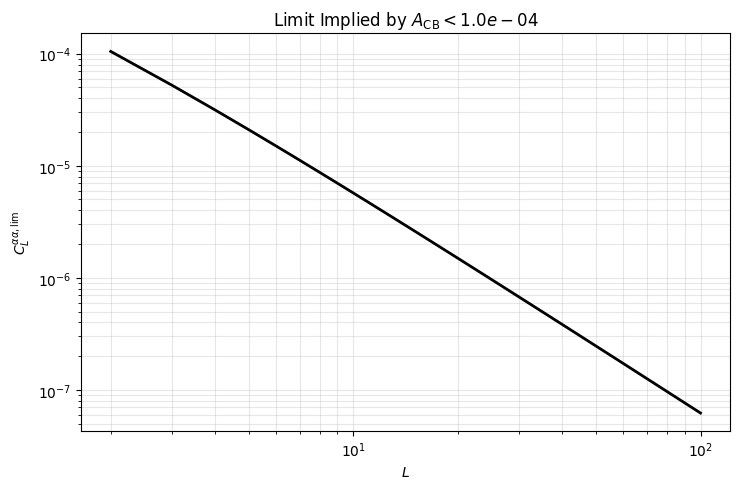

In [2]:
plt.figure(figsize=(7.5, 5))
plt.loglog(L, Claa_lim, color="black", lw=2)
plt.xlabel(r"$L$")
plt.ylabel(r"$C_L^{\alpha\alpha,\rm lim}$")
plt.title(rf"Limit Implied by $A_{{\rm CB}} < {A_CB_LIMIT:.1e}$")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
        


## patchy-only のときの $A_\tau^2 C_L^{\tau\tau}$ bound

この段階ではまだ `A_\tau` を固定していないので、実際に直接制限しているのは

```math
A_\tau^2 C_L^{\tau\tau}
```

の組み合わせです。
        


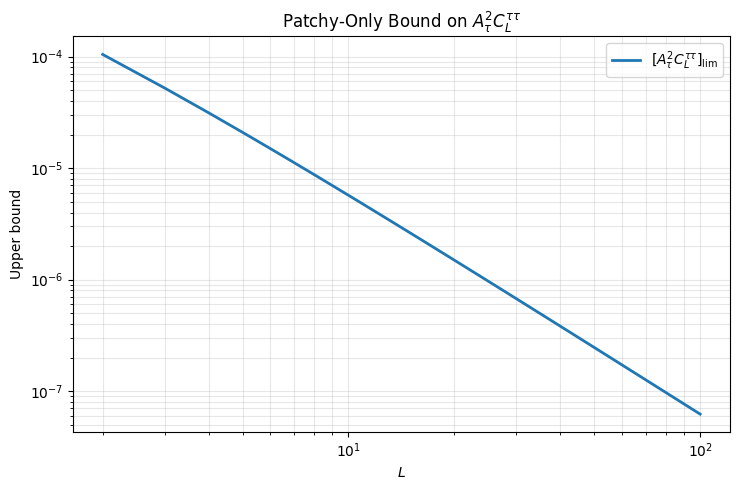

In [3]:
plt.figure(figsize=(7.5, 5))
plt.loglog(L, Claa_lim, color="tab:blue", lw=2, label=r"$[A_\tau^2 C_L^{\tau\tau}]_{\rm lim}$")
plt.xlabel(r"$L$")
plt.ylabel(r"Upper bound")
plt.title(r"Patchy-Only Bound on $A_\tau^2 C_L^{\tau\tau}$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
        


## 任意の $|A_\tau|$ を入れたときの $C_L^{\tau\tau}$ bound

benchmark として `|A_\tau|` を仮に与えると

```math
C_L^{\tau\tau,\lim}
=
\frac{C_L^{\alpha\alpha,\lim}}{A_\tau^2}
```

となります。
        


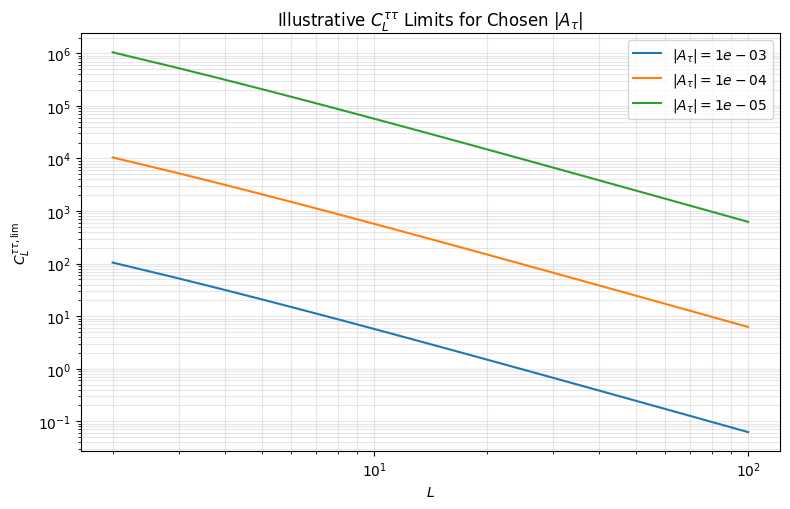

In [4]:
atau_values = [1e-3, 1e-4, 1e-5]

plt.figure(figsize=(8, 5.2))
for atau in atau_values:
    plt.loglog(L, Claa_lim / (atau**2), label=rf"$|A_\tau|={atau:.0e}$")

plt.xlabel(r"$L$")
plt.ylabel(r"$C_L^{\tau\tau,\rm lim}$")
plt.title(r"Illustrative $C_L^{\tau\tau}$ Limits for Chosen $|A_\tau|$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
        


## scale-invariant 仮定を置いたときの見通し

もし genuine term と patchy term の両方が同じ template

```math
C_L^{\rm temp}
```

に従って

```math
C_L^{\phi\phi} = c_\phi C_L^{\rm temp},
\qquad
C_L^{\tau\tau} = c_\tau C_L^{\rm temp},
\qquad
C_L^{\phi\tau}=0
```

と書けるなら、

```math
C_L^{\alpha\alpha}
=
\left(A_\phi^2 c_\phi + A_\tau^2 c_\tau\right) C_L^{\rm temp}
```

なので、

```math
A_\phi^2 c_\phi + A_\tau^2 c_\tau \le A_{\rm CB}^{\lim}
```

という見通しの良い式になります。

特に `c_\phi = c_\tau = 1` まで仮定できれば、

```math
A_\phi^2 + A_\tau^2 \le A_{\rm CB}^{\lim}
```

という benchmark 的な bound になります。
        


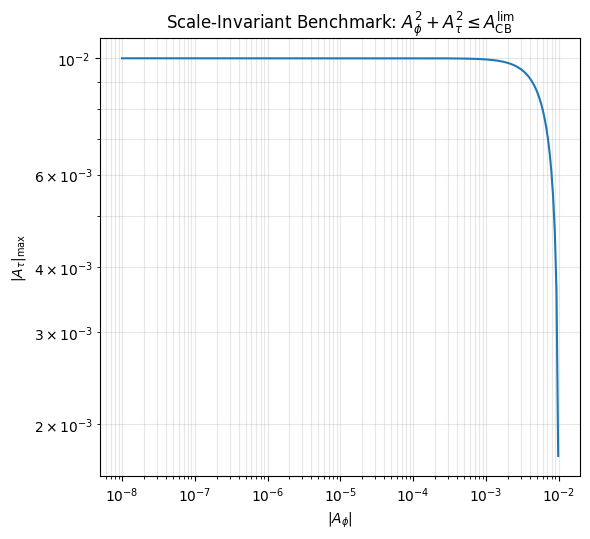

In [7]:
Aphi_grid = np.logspace(-8, -1, 300)
Atau_limit = np.sqrt(np.maximum(A_CB_LIMIT - Aphi_grid**2, 0.0))

plt.figure(figsize=(6, 5.5))
plt.loglog(Aphi_grid[Aphi_grid < np.sqrt(A_CB_LIMIT)], Atau_limit[Aphi_grid < np.sqrt(A_CB_LIMIT)])
plt.xlabel(r"$|A_\phi|$")
plt.ylabel(r"$|A_\tau|_{\rm max}$")
plt.title(r"Scale-Invariant Benchmark: $A_\phi^2 + A_\tau^2 \leq A_{\rm CB}^{\lim}$")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
        


## isotropic CB benchmark への橋渡し

次に考えたい benchmark は、reported isotropic CB signal

```math
0.26 \pm 0.06\ {\rm deg}
```

を ALP-photon coupling で説明するときの `g_{a\gamma}` を使うことです。

その場合の流れは

1. isotropic CB の中心値を再現する `g_{a\gamma}` を決める
2. その `g_{a\gamma}` から `A_\phi` と `A_\tau` を固定する
3. anisotropic CB の `A_{\rm CB}` 上限を使って `C_L^{\tau\tau}` へ制限を落とす

となります。

この notebook ではまだそこまで数値化していませんが、上の図はその benchmark をどこへ接続すればよいかを示しています。
        


In [8]:
selected_table = [
    {"requested_mass": req, "matched_mass": matched, "A_unit": a_unit}
    for req, (matched, a_unit) in zip(BEST_MASSES_REQUESTED, selected)
]
selected_table
        


[{'requested_mass': 2.0309176209047306e-27,
  'matched_mass': np.float64(2.0309176209047306e-27),
  'A_unit': np.float64(11050048439.7749)},
 {'requested_mass': 5.878016072274924e-27,
  'matched_mass': np.float64(5.878016072274924e-27),
  'A_unit': np.float64(13935403275.476799)},
 {'requested_mass': 1e-26,
  'matched_mass': np.float64(1e-26),
  'A_unit': np.float64(-2632126036.501822)}]